

IMPORT REQUIRED LIBRARIES
==========================================
This cell imports all necessary libraries for data manipulation, visualization,
preprocessing, modeling, and evaluation throughout the project.


In [ ]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, classification_report

In [ ]:
df = pd.read_csv(r"C:\Users\zakih\OneDrive\Desktop\projects\Telco Customer Churn\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Analysis:** Dataset contains 7,043 customers with 21 features. Most columns are categorical (object type). `TotalCharges` is stored as object but should be numeric - needs conversion.


In [ ]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:

(df==" ").sum()


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [ ]:

df['TotalCharges'] = df["TotalCharges"].replace(" ",np.nan)


In [ ]:
df.isnull().sum()
df = df.dropna()
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [ ]:
df=df.drop('customerID',axis=1)


In [ ]:
columns=df.columns
print(columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


In [ ]:
df['TotalCharges'] = df['TotalCharges'].astype(float)
df.dtypes

gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [ ]:
df.apply(lambda col: col.unique())


gender                                                 [Female, Male]
SeniorCitizen                                                  [0, 1]
Partner                                                     [Yes, No]
Dependents                                                  [No, Yes]
tenure              [1, 34, 2, 45, 8, 22, 10, 28, 62, 13, 16, 58, ...
PhoneService                                                [No, Yes]
MultipleLines                             [No phone service, No, Yes]
InternetService                                [DSL, Fiber optic, No]
OnlineSecurity                         [No, Yes, No internet service]
OnlineBackup                           [Yes, No, No internet service]
DeviceProtection                       [No, Yes, No internet service]
TechSupport                            [No, Yes, No internet service]
StreamingTV                            [No, Yes, No internet service]
StreamingMovies                        [No, Yes, No internet service]
Contract            

**Analysis:** Class imbalance detected: 73.4% no-churn vs 26.6% churn. This imbalance requires special handling (SMOTE, class weights) to prevent model bias toward majority class.


In [ ]:
churn_counts=df['Churn'].value_counts()
print(churn_counts)

Churn
No     5163
Yes    1869
Name: count, dtype: int64


In [ ]:
churn_percentage=df['Churn'].value_counts(normalize=True)*100
print(churn_percentage)

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64



VISUALIZE CHARGES BY CHURN STATUS
==========================================
Creates a bar plot comparing MonthlyCharges and TotalCharges
between customers who churned and those who stayed.
This visualization helps identify if charges are related to churn behavior.


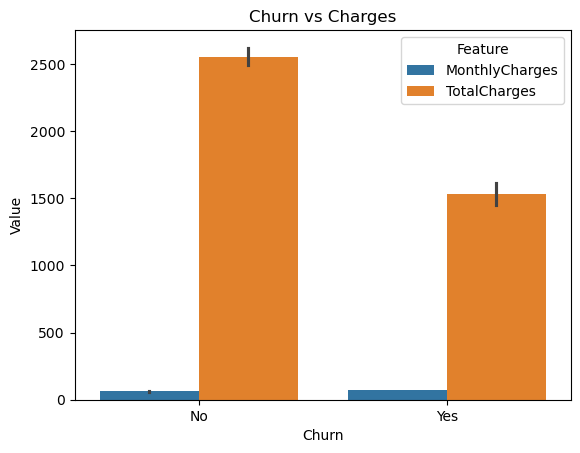

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Transform data from wide to long format for easier plotting
df_plot = df[['Churn', 'MonthlyCharges', 'TotalCharges']]
df_long = df_plot.melt(id_vars='Churn', var_name='Feature', value_name='Value')

sns.barplot(x='Churn', y='Value', hue='Feature', data=df_long)
plt.title('Churn vs Charges')
plt.show()


C:\Users\zakih\AppData\Local\Temp\ipykernel_22584\3775517372.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn']=df['Churn'].replace({'Yes' : 1 , 'No' : 0})


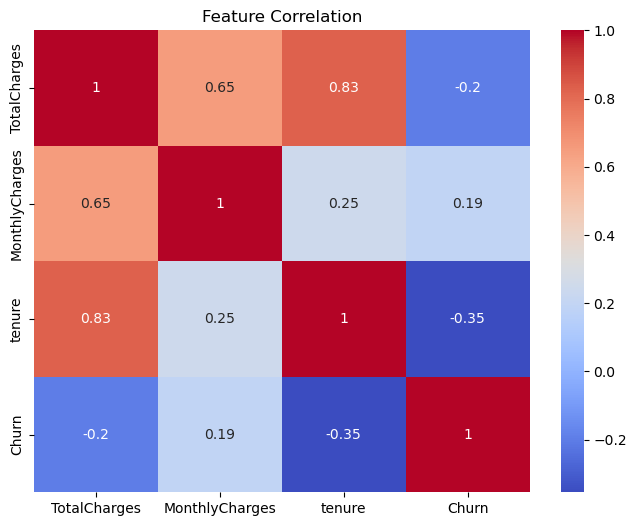

In [ ]:
"""
==========================================
CORRELATION HEATMAP FOR NUMERICAL FEATURES
==========================================
Creates a correlation heatmap to visualize relationships between
key numerical features and the target variable (Churn).
Correlation values range from -1 to +1, indicating negative to positive relationships.
"""

# Convert Churn to numeric for correlation calculation
df['Churn']=df['Churn'].replace({'Yes' : 1 , 'No' : 0})

plt.figure(figsize=(8,6))
sns.heatmap(df[['TotalCharges','MonthlyCharges','tenure','Churn']].corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

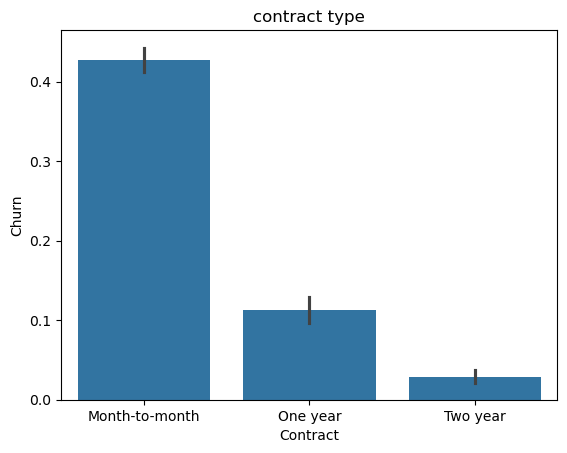

In [ ]:
"""
==========================================
VISUALIZE CHURN BY CONTRACT TYPE
==========================================
Creates a bar plot showing the relationship between contract type
and churn rate. This helps identify if certain contract types
are associated with higher or lower churn rates.
"""

sns.barplot(x='Contract', y='Churn', data=df)
plt.title('contract type')
plt.show()

In [ ]:
"""
==========================================
SEPARATE FEATURES AND TARGET VARIABLE
==========================================
Splits the dataset into features (X) and target variable (y).
This is a fundamental step before training machine learning models.
Features are the input variables, and the target is what we want to predict.
"""

# -------------------------------
# Separate Features and Target
# -------------------------------

target_column = 'Churn'
y = df[target_column]
X = df.drop(columns=[target_column])

print("Features (X) columns:")
print(X.columns)
print("\nTarget (y) preview:")
print(y.head())


Features (X) columns:
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges'],
      dtype='object')

Target (y) preview:
0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [ ]:
"""
==========================================
IDENTIFY CATEGORICAL FEATURES
==========================================
Identifies all columns with object/string data type, which are typically
categorical variables. These features will need encoding (conversion to numbers)
before they can be used in machine learning models.
"""

categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_features)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
"""
==========================================
REVIEW UNIQUE VALUES AFTER PREPROCESSING
==========================================
Re-examines unique values in each column after initial preprocessing.
This helps verify data transformations and identify remaining categorical
values that need encoding before model training.
"""

df.apply(lambda col: col.unique())

gender                                                 [Female, Male]
SeniorCitizen                                                  [0, 1]
Partner                                                     [Yes, No]
Dependents                                                  [No, Yes]
tenure              [1, 34, 2, 45, 8, 22, 10, 28, 62, 13, 16, 58, ...
PhoneService                                                [No, Yes]
MultipleLines                             [No phone service, No, Yes]
InternetService                                [DSL, Fiber optic, No]
OnlineSecurity                         [No, Yes, No internet service]
OnlineBackup                           [Yes, No, No internet service]
DeviceProtection                       [No, Yes, No internet service]
TechSupport                            [No, Yes, No internet service]
StreamingTV                            [No, Yes, No internet service]
StreamingMovies                        [No, Yes, No internet service]
Contract            

In [ ]:
"""
==========================================
ENCODE BINARY CATEGORICAL FEATURES
==========================================
Converts binary categorical features (Yes/No, Male/Female) to numeric format (1/0).
This is necessary because machine learning algorithms require numeric input.
Binary encoding is simpler than one-hot encoding for two-category variables.
"""

df['PaperlessBilling']=df['PaperlessBilling'].replace({'Yes' : 1 , 'No' : 0})
df['PhoneService']=df['PhoneService'].replace({'Yes' : 1 , 'No' : 0})
df['Dependents']=df['Dependents'].replace({'Yes' : 1 , 'No' : 0})
df['Partner']=df['Partner'].replace({'Yes' : 1 , 'No' : 0})
df['gender']=df['gender'].replace({'Female' : 1 , 'Male' : 0})

C:\Users\zakih\AppData\Local\Temp\ipykernel_22584\4028413842.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['PaperlessBilling']=df['PaperlessBilling'].replace({'Yes' : 1 , 'No' : 0})
C:\Users\zakih\AppData\Local\Temp\ipykernel_22584\4028413842.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['PhoneService']=df['PhoneService'].replace({'Yes' : 1 , 'No' : 0})
C:\Users\zakih\AppData\Local\Temp\ipykernel_22584\4028413842.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future 

In [ ]:
"""
==========================================
ONE-HOT ENCODE MULTI-CATEGORY FEATURES
==========================================
Applies one-hot encoding to categorical features with more than two categories.
One-hot encoding creates binary columns for each category (e.g., Contract_One year, Contract_Two year).
drop_first=True removes one column to avoid multicollinearity (redundancy).
"""

df_encoded = pd.get_dummies(df, columns=['PaymentMethod', 'Contract','StreamingMovies','StreamingTV','TechSupport','DeviceProtection','OnlineBackup','OnlineSecurity','InternetService','MultipleLines'], drop_first=True)
print(df_encoded)

      gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0          1              0        1           0       1             0   
1          0              0        0           0      34             1   
2          0              0        0           0       2             1   
3          0              0        0           0      45             0   
4          1              0        0           0       2             1   
...      ...            ...      ...         ...     ...           ...   
7038       0              0        1           1      24             1   
7039       1              0        1           1      72             1   
7040       1              0        1           1      11             0   
7041       0              1        1           0       4             1   
7042       0              0        0           0      66             1   

      PaperlessBilling  MonthlyCharges  TotalCharges  Churn  ...  \
0                    1           29.85     

In [ ]:
"""
==========================================
SEPARATE FEATURES AND TARGET (AFTER ENCODING)
==========================================
Splits the fully encoded dataset into features (X) and target (y).
This is done after all encoding is complete, so all features are now numeric
and ready for machine learning algorithms.
"""

# -------------------------------
# Separate Features and Target
# -------------------------------

target_column = 'Churn'
y = df_encoded[target_column]
X = df_encoded.drop(columns=[target_column])

print("Features (X) columns:")
print(X.columns)
print("\nTarget (y) preview:")
print(y.head())


Features (X) columns:
Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Contract_One year', 'Contract_Two year',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'MultipleLines_No phone service', 'MultipleLines_Yes'],
      dtype='object')

Target (y) preview:
0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64


In [ ]:
"""
==========================================
SPLIT DATA INTO TRAINING AND TEST SETS
==========================================
Divides the dataset into training (80%) and testing (20%) sets.
Training set is used to teach the model, test set is used to evaluate
its performance on unseen data. random_state=42 ensures reproducibility.
"""

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Analysis:** Logistic Regression baseline: 74% accuracy. Good precision for no-churn (0.90) but poor for churn (0.51). High recall for churn (0.76) means it catches most churners but with many false positives.


**Analysis:** Random Forest improves to 78% accuracy. Better balance: no-churn precision 0.82, churn precision 0.63. However, churn recall drops to 0.45, missing more churners than Logistic Regression.


In [ ]:
"""
==========================================
TRAIN LOGISTIC REGRESSION MODEL (BASELINE)
==========================================
Trains a Logistic Regression model as a baseline classifier.
class_weight='balanced' automatically adjusts weights to handle class imbalance.
This is a simple linear model that provides a performance benchmark.
"""

model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

c:\Users\zakih\anaconda3\envs\deep-learning-course-2025\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


**Analysis:** SMOTE successfully balanced classes (4,130 each). This should help the model learn better patterns from the minority class without just duplicating samples.


**Analysis:** With SMOTE, churn recall improved to 0.73 (from 0.45), catching more churners. Accuracy slightly decreased to 75% but F1-score improved to 0.61, indicating better overall balance.


In [ ]:
"""
==========================================
EVALUATE LOGISTIC REGRESSION MODEL
==========================================
Evaluates the Logistic Regression model's performance on the test set.
Provides accuracy, confusion matrix, and detailed classification metrics
including precision, recall, and F1-score for each class.
"""

from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7420042643923241

Confusion Matrix:
[[759 274]
 [ 89 285]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1033
           1       0.51      0.76      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.79      0.74      0.75      1407



**Analysis:** GridSearchCV found optimal parameters: 500 trees, unlimited depth, log2 features. Best F1-score: 0.84 (CV). Test accuracy: 76.3% with balanced precision (0.84) and recall (0.56) for churn. Best overall model.


**Analysis:** Top churn drivers: Payment method (Electronic check: 21%), Tenure (13%), Fiber optic service (11%), Two-year contract (10%). Customers with electronic checks and fiber optic are highest risk. Longer tenure and contracts reduce churn.


In [ ]:
"""
==========================================
TRAIN AND EVALUATE RANDOM FOREST MODEL
==========================================
Trains a Random Forest Classifier, which is an ensemble method that combines
multiple decision trees. Random Forest typically performs better than simple
linear models and can capture non-linear relationships in the data.
"""

model = RandomForestClassifier(class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7839374555792467

Confusion Matrix:
[[934  99]
 [205 169]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.45      0.53       374

    accuracy                           0.78      1407
   macro avg       0.73      0.68      0.69      1407
weighted avg       0.77      0.78      0.77      1407



In [ ]:
"""
==========================================
APPLY SMOTE FOR CLASS IMBALANCE HANDLING
==========================================
Uses SMOTE (Synthetic Minority Oversampling Technique) to balance the classes.
SMOTE creates synthetic samples of the minority class (churners) rather than
just duplicating existing samples, which helps the model learn better patterns.
"""

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(y_train_res.value_counts())



Churn
1    4130
0    4130
Name: count, dtype: int64


In [ ]:
"""
==========================================
TRAIN RANDOM FOREST WITH SMOTE DATA
==========================================
Trains a Random Forest model on the SMOTE-balanced training data.
This model uses specific hyperparameters (100 trees, max depth of 5) to
prevent overfitting while still capturing important patterns.
"""

model = RandomForestClassifier(class_weight='balanced',n_estimators=100,max_depth=5, random_state=42)
model.fit(X_train_res, y_train_res)

from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.749822316986496

Confusion Matrix:
[[781 252]
 [100 274]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1033
           1       0.52      0.73      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407



In [ ]:
"""
==========================================
HYPERPARAMETER TUNING WITH GRIDSEARCHCV
==========================================
Performs exhaustive hyperparameter tuning using GridSearchCV to find
the optimal combination of Random Forest parameters. This systematically
tests different parameter combinations using cross-validation to find
the best model configuration.
"""

# -------------------------------
# Hyperparameter Tuning with GridSearchCV
# -------------------------------

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1 Define the base model with fixed parameters
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')

# 2️ Create the parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# 3️ Set up GridSearchCV
# scoring='f1' because we care about churners (minority class)
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

# 4️ Fit GridSearchCV on the oversampled training data
grid_search.fit(X_train_res, y_train_res)

# 5️ Display the best hyperparameters and their performance
print("Best Hyperparameters:", grid_search.best_params_)
print("Best F1 Score:", grid_search.best_score_)

# 6️ Extract the best model and make predictions on the test set
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# 7️ Evaluate the best model's performance on the test set
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Fitting 5 folds for each of 243 candidates, totalling 1215 fits
Best Hyperparameters: {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}
Best F1 Score: 0.8389830429010388
Accuracy: 0.7633262260127932

Confusion Matrix:
[[864 169]
 [164 210]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.84      0.84      1033
           1       0.55      0.56      0.56       374

    accuracy                           0.76      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.76      0.76      0.76      1407



In [ ]:
"""
==========================================
ANALYZE FEATURE IMPORTANCE
==========================================
Extracts and displays feature importance scores from the Random Forest model.
Feature importance indicates how much each feature contributes to the model's
predictions. Higher importance means the feature is more influential in
determining whether a customer will churn.
"""

importances = model.feature_importances_
feature_names = X_train.columns

feature_importance_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

print("Top Features Affecting Churn:")
print(feature_importance_series.head(10))


Top Features Affecting Churn:
PaymentMethod_Electronic check          0.210615
tenure                                  0.134107
InternetService_Fiber optic             0.109074
Contract_Two year                       0.102937
TotalCharges                            0.076271
Partner                                 0.059072
Dependents                              0.056635
MonthlyCharges                          0.035098
Contract_One year                       0.025777
DeviceProtection_No internet service    0.023427
dtype: float64


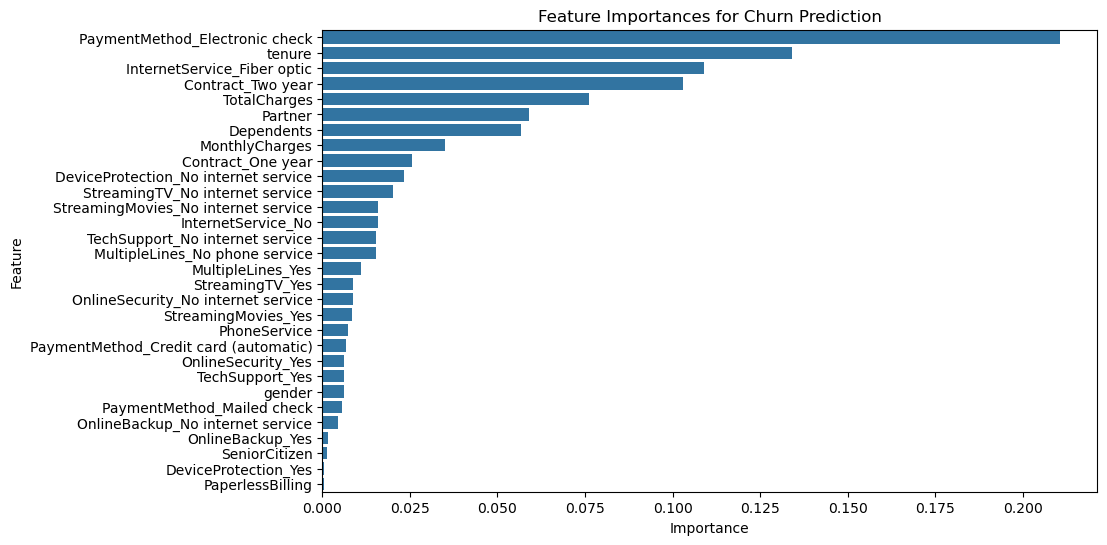

In [ ]:
"""
==========================================
VISUALIZE FEATURE IMPORTANCE
==========================================
Creates a horizontal bar plot showing the importance of each feature
in predicting customer churn. This visualization helps identify which
customer attributes are most critical for churn prediction.
"""

plt.figure(figsize=(10,6))
sns.barplot(x=feature_importance_series.values, y=feature_importance_series.index)
plt.title('Feature Importances for Churn Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()


In [ ]:
"""
==========================================
COLLECT USER INPUT FOR PREDICTION
==========================================
Prompts the user to enter customer information for a churn prediction.
This creates a dictionary with the input values that will be processed
and used to make a prediction using the trained model.
"""

user_inputs = {
    'tenure': int(input("Enter tenure (months): ")),
    'MonthlyCharges': float(input("Enter monthly charges: ")),
    'TotalCharges': float(input("Enter total charges: ")),
    'Contract': input("Contract type (Month-to-month / One year / Two year): "),
    'PaymentMethod': input("Payment method (Electronic check / Mailed check / Bank transfer / Credit card): "),
    'InternetService': input("Internet service (DSL / Fiber optic / No): ")
}


In [ ]:
"""
==========================================
PREPROCESS USER INPUT FOR PREDICTION
==========================================
Transforms user input into the same format as the training data.
This includes encoding binary features, creating one-hot encoded columns,
and aligning with the exact feature structure the model expects.
"""

# Step 1: Encode binary inputs (Yes/No, Male/Female) to numeric (1/0)
binary_map = {'Yes': 1, 'No': 0, 'Female': 1, 'Male': 0}
for col in ['gender','Partner','Dependents','PhoneService','PaperlessBilling']:
    if col in user_inputs:
        user_inputs[col] = binary_map[user_inputs[col]]

# Step 2: Convert the dictionary to a pandas DataFrame
input_df = pd.DataFrame([user_inputs])

# Step 3: Identify and encode categorical columns that exist in user input
categorical_cols = [col for col in ['PaymentMethod', 'Contract', 'StreamingMovies', 
                                    'StreamingTV', 'TechSupport', 'DeviceProtection', 
                                    'OnlineBackup', 'OnlineSecurity', 'InternetService', 
                                    'MultipleLines'] if col in input_df.columns]

input_encoded = pd.get_dummies(input_df, columns=categorical_cols, drop_first=True)

# Step 4: Align columns with training data structure
# Reindex to match X_train columns exactly, filling missing columns with 0
input_encoded = input_encoded.reindex(columns=X_train.columns, fill_value=0)

print(input_encoded)


   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       0              0        0           0       8             0   

   PaperlessBilling  MonthlyCharges  TotalCharges  \
0                 0            30.8        1000.0   

   PaymentMethod_Credit card (automatic)  ...  \
0                                      0  ...   

   DeviceProtection_No internet service  DeviceProtection_Yes  \
0                                     0                     0   

   OnlineBackup_No internet service  OnlineBackup_Yes  \
0                                 0                 0   

   OnlineSecurity_No internet service  OnlineSecurity_Yes  \
0                                   0                   0   

   InternetService_Fiber optic  InternetService_No  \
0                            0                   0   

   MultipleLines_No phone service  MultipleLines_Yes  
0                               0                  0  

[1 rows x 30 columns]


In [ ]:
"""
==========================================
MAKE CHURN PREDICTION
==========================================
Uses the trained model to predict whether the customer will churn.
Provides both the binary prediction (churn or no churn) and the probability
score, which indicates the model's confidence in the prediction.
"""

prediction = model.predict(input_encoded)
prediction_proba = model.predict_proba(input_encoded)[:,1]  # probability of churn

if prediction[0] == 1:
    print(f"Customer is likely to CHURN! Probability: {prediction_proba[0]:.2f}")
else:
    print(f"Customer is likely to STAY! Probability: {prediction_proba[0]:.2f}")


Customer is likely to STAY! Probability: 0.44


In [ ]:
"""
==========================================
SAVE TRAINED MODEL TO FILE
==========================================
Saves the trained model and feature column names to a pickle file.
This allows the model to be loaded later for predictions without
retraining. Saving the column names ensures proper data alignment
when making predictions on new data.
"""

import pickle

model_data = {
    "model": model,
    "columns": X_train.columns
}

with open("churn_model.pkl", "wb") as f:
    pickle.dump(model_data, f)
